In [ ]:
import numpy as np
import pandas as pd
from glaciation_time_estimator.auxiliary_func.config_reader import read_config
from glaciation_time_estimator.auxiliary_func.chunking_data import ChunkLoader
import os

In [34]:
config = read_config(
   '/wolke_scratch/dnikolo/Glaciation_time_estimator/configs/map_generation/map_gen_config.yaml')
analyze_year=True
years = [year for year in range(2007, 2017)]
glac_threshold=0.4

In [35]:
def extract_heatmap(dfs):
    cloud_df , _ , _ = dfs
    lon_bins = np.arange(-80, 82, 1)
    lat_bins = np.arange(-80, 82, 1)

    # 2. Compute the 2D histogram
    heatmap, lon_edges, lat_edges = np.histogram2d(
        cloud_df['avg_lon'],
        cloud_df['avg_lat'],
        bins=[lon_bins, lat_bins]
    )
    return heatmap

In [37]:
def extract_glac_heatmap(dfs):
    _ , glac_df , _ = dfs
    lon_bins = np.arange(-80, 82, 1)
    lat_bins = np.arange(-80, 82, 1)

    # 2. Compute the 2D histogram
    heatmap_glac, lon_edges, lat_edges = np.histogram2d(
        glac_df['avg_lon'],
        glac_df['avg_lat'],
        bins=[lon_bins, lat_bins]
    )

    return  heatmap_glac

In [44]:
def extract_cloud_heatmap_by_temp_month(dfs):
    cloud_df , _ , _ = dfs
    lon_bins = np.arange(-80, 82, 1)
    lat_bins = np.arange(-80, 82, 1)
    result = {}
    months = [i for i in range(1,13)]
    for i in range(0,-31,-6):
        heatmap_glac=[]
        # Filter once by temperature
        temp_df = cloud_df[cloud_df['max_temp'] == i]

        for  month in months:
            # Filter by season months using .dt.month.isin(...)
            season_df = temp_df[temp_df['track_start_time'].dt.month == month]
            heatmap_glac_month, lon_edges, lat_edges = np.histogram2d(
                season_df['avg_lon'],
                season_df['avg_lat'],
                bins=[lon_bins, lat_bins]
            )
            heatmap_glac.append(heatmap_glac_month)
        heatmap_glac=np.array(heatmap_glac)
        result[i] = heatmap_glac
    return result

In [45]:
def extract_glac_heatmap_by_temp_month(dfs):
    _ , glac_df , _ = dfs
    lon_bins = np.arange(-80, 82, 1)
    lat_bins = np.arange(-80, 82, 1)
    result = {}
    months = [i for i in range(1,13)]
    for i in range(0,-31,-6):
        heatmap_glac=[]
        # Filter once by temperature
        temp_df = glac_df[glac_df['max_temp'] == i]

        for  month in months:
            # Filter by season months using .dt.month.isin(...)
            season_df = temp_df[temp_df['track_start_time'].dt.month == month]
            heatmap_glac_month, lon_edges, lat_edges = np.histogram2d(
                season_df['avg_lon'],
                season_df['avg_lat'],
                bins=[lon_bins, lat_bins]
            )
            heatmap_glac.append(heatmap_glac_month)
        heatmap_glac=np.array(heatmap_glac)
        result[i] = heatmap_glac
    return result

In [40]:
def extract_glac_heatmap_by_temp_season(dfs):
    _ , glac_df , _ = dfs
    lon_bins = np.arange(-80, 82, 1)
    lat_bins = np.arange(-80, 82, 1)
    result = {}
    seasons = [[12,1,2],[3,4,5],[6,7,8],[9,10,11]]
    for i in range(0,-31,-6):
        heatmap_glac=[]
        # Filter once by temperature
        temp_df = glac_df[glac_df['max_temp'] == i]

        for  months in seasons:
            # Filter by season months using .dt.month.isin(...)
            season_df = temp_df[temp_df['track_start_time'].dt.month.isin(months)]
            heatmap_glac_month, lon_edges, lat_edges = np.histogram2d(
                season_df['avg_lon'],
                season_df['avg_lat'],
                bins=[lon_bins, lat_bins]
            )
            heatmap_glac.append(heatmap_glac_month)
        heatmap_glac=np.array(heatmap_glac)
        result[i] = heatmap_glac
    return result

In [ ]:
def extract_cloud_heatmap_by_temp_season(dfs):
    cloud_df , _ , _ = dfs
    lon_bins = np.arange(-80, 82, 1)
    lat_bins = np.arange(-80, 82, 1)
    result = {}
    seasons = [[12,1,2],[3,4,5],[6,7,8],[9,10,11]]
    for i in range(0,-31,-6):
        heatmap_cloud=[]
        # Filter once by temperature
        temp_df = cloud_df[cloud_df['max_temp'] == i]

        for months in seasons:
            # Filter by season months using .dt.month.isin(...)
            season_df = temp_df[temp_df['track_start_time'].dt.month.isin(months)]
            heatmap_cloud_month, lon_edges, lat_edges = np.histogram2d(
                season_df['avg_lon'],
                season_df['avg_lat'],
                bins=[lon_bins, lat_bins]
            )
            heatmap_cloud.append(heatmap_cloud_month)
        heatmap_cloud=np.array(heatmap_cloud)
        result[i] = heatmap_cloud
    return result

In [42]:
dataset = ChunkLoader(years,config=config, load_init_chunk=True)

Cloud_fps: {2007: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2007_all.parquet', 2008: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2008_all.parquet', 2009: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2009_all.parquet', 2010: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2010_all.parquet', 2011: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2011_all.parquet', 2012: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2012_all.parquet', 2013: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2013_all.parquet', 2014: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2014_all.parquet', 2015: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2015_all.parquet', 2016: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2016_all.parquet'}


In [46]:
heatmaps_glac_by_temp = dataset.execute_analysis(extract_glac_heatmap_by_temp_month,load_glac=True, load_clouds=False)#,glac_columns=["avg_lon","avg_lat"])

Loading years: 100%|██████████| 10/10 [00:19<00:00,  1.90s/year]


In [47]:
heatmaps_cloud_by_temp = dataset.execute_analysis(extract_cloud_heatmap_by_temp_month,load_glac=False, load_clouds=True)#,glac_columns=["avg_lon","avg_lat"])

Loading years: 100%|██████████| 10/10 [14:42<00:00, 88.23s/year]


In [48]:
heatmaps_cloud_by_temp_dict={}
for i in range(0,-31,-6):
    temp_list=[]
    for j in range(len(heatmaps_cloud_by_temp)):
        temp_list.append(heatmaps_cloud_by_temp[j][i])
        temp_arr = np.concatenate(temp_list,axis=0)
    heatmaps_cloud_by_temp_dict[i]=temp_arr

In [49]:
heatmaps_glac_by_temp_dict={}
for i in range(0,-31,-6):
    temp_list=[]
    for j in range(len(heatmaps_glac_by_temp)):
        temp_list.append(heatmaps_glac_by_temp[j][i])
        temp_arr = np.concatenate(temp_list,axis=0)
    heatmaps_glac_by_temp_dict[i]=temp_arr

In [50]:
temp_keys = [0, -6, -12, -18, -24, -30]
cloud_list = [heatmaps_cloud_by_temp_dict[k] for k in temp_keys]
glac_list = [heatmaps_glac_by_temp_dict[k] for k in temp_keys]

# Each element shape: (season_time, nlat, nlon)
cloud_data = np.stack(cloud_list, axis=-1)  # (time, lat, lon, temp_range)
glac_data = np.stack(glac_list, axis=-1)    # (time, lat, lon, temp_range)
np.save("/wolke_scratch/dnikolo/dump/cloud_data_monthly.npy",cloud_data)
np.save("/wolke_scratch/dnikolo/dump/glac_data_monthly.npy",glac_data)

In [52]:
def lats_lons(dfs):
    cloud_df , _ , _ = dfs
    lon_bins = np.arange(-80, 82, 1)
    lat_bins = np.arange(-80, 82, 1)

    # 2. Compute the 2D histogram
    heatmap, lon_edges, lat_edges = np.histogram2d(
        cloud_df['avg_lon'],
        cloud_df['avg_lat'],
        bins=[lon_bins, lat_bins]
    )
    return heatmap, lon_edges,lat_edges
_, lon_edges,lat_edges = lats_lons((dataset.cloud_chunk,None,None))
# 5) Create xarray Dataset with both variables
lat = (lat_edges[1:]+lat_edges[0:-1])/2  # latitude
lon = (lon_edges[1:]+lon_edges[0:-1])/2  # longitudes

In [53]:
cloud_data = np.load("/wolke_scratch/dnikolo/dump/cloud_data.npy")
glac_data = np.load("/wolke_scratch/dnikolo/dump/glac_data.npy")

FileNotFoundError: [Errno 2] No such file or directory: '/wolke_scratch/dnikolo/dump/cloud_data.npy'

In [54]:
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime
cloud_data = np.load("/wolke_scratch/dnikolo/dump/cloud_data_seasonal.npy")
glac_data = np.load("/wolke_scratch/dnikolo/dump/glac_data_seasonal.npy")
# --------------------------------------------------------------------
# Assumptions / inputs (already prepared elsewhere):
#   - heatmaps_cloud_by_temp_dict: dict keyed by temp (0, -6, ..., -30)
#       value shape: (Nseasons, Nlon, Nlat) with seasons in order
#       [DJF, MAM, JJA, SON] for each year, for 10 years -> Nseasons = 40
#
#   - heatmaps_glac_by_temp_dict: same structure as above
#
#   - years: list of the 10 calendar years in correct order, e.g.
#       years = [2000, 2001, ..., 2009]
#
#   - lon, lat: 1D arrays giving bin centers (or edges midpoints)
# --------------------------------------------------------------------

# Temperature bins (must match how you built the dicts)
temp_keys = [0, -6, -12, -18, -24, -30]  # warmest bin first

# --- 1) Stack temperature bins into 4D arrays: (season, lon, lat, temp_range)



n_seasons, nlon, nlat, ntemp = cloud_data.shape

# --- 2) Build seasonal time + season label coordinates

n_years = len(years)
expected_n_seasons = n_years * 4  # DJF, MAM, JJA, SON per year

if n_seasons != expected_n_seasons:
    raise ValueError(
        f"Season dimension ({n_seasons}) does not equal years*4 "
        f"({expected_n_seasons})."
    )

time_list = []
season_labels = []

for year in years:
    # Representative dates (mid-season); adjust if you prefer different days
    # DJF: Dec–Jan–Feb
    time_list.append(pd.Timestamp(year=year, month=2, day=15))
    season_labels.append("DJF")

    # MAM: Mar–Apr–May
    time_list.append(pd.Timestamp(year=year, month=5, day=15))
    season_labels.append("MAM")

    # JJA: Jun–Jul–Aug
    time_list.append(pd.Timestamp(year=year, month=8, day=15))
    season_labels.append("JJA")

    # SON: Sep–Oct–Nov
    time_list.append(pd.Timestamp(year=year, month=11, day=15))
    season_labels.append("SON")

time = pd.DatetimeIndex(time_list, name="time")

# --- 3) Temperature range coordinates

temp_labels = []
temp_midpoints = []
for k in temp_keys:
    lower = k - 6
    upper = k
    temp_labels.append(f"{lower} to {upper} degC")
    temp_midpoints.append((lower + upper) / 2.0)

temp_midpoints = np.array(temp_midpoints, dtype=float)

# --- 4) Reorder data so lon = X, lat = Y, time = season index
# currently: (season, lon, lat, temp_range)
# desired:   (lon, lat, time, temp_range)

# cloud_data_reordered = np.transpose(cloud_data, (1, 2, 0, 3))
# glac_data_reordered  = np.transpose(glac_data,  (1, 2, 0, 3))

# --- 5) Create Dataset with dims (lon, lat, time, temp_range)

ds = xr.Dataset(
    data_vars={
        "clouds": (
            # ("lon", "lat", "time", "temp_range"),
            ("time", "lat", "lon", "temp_range"),
            cloud_data
        ),
        "glaciation": (
            # ("lon", "lat", "time", "temp_range"),
            ("time", "lat", "lon", "temp_range"),
            glac_data
        ),
    },
    coords={
        "lon": ("lon", lon),
        "lat": ("lat", lat),
        "time": ("time", time),
        "temp_range": ("temp_range", temp_midpoints),
        "temp_range_label": ("temp_range", temp_labels),
        # string coordinate along the time dimension with season names
        "season": ("time", season_labels),
    },
)

# --- 6) CF-style metadata for coordinates

ds["lon"].attrs.update({
    "standard_name": "longitude",
    "long_name": "longitude",
    "units": "degrees_east",
    "axis": "X"
})

ds["lat"].attrs.update({
    "standard_name": "latitude",
    "long_name": "latitude",
    "units": "degrees_north",
    "axis": "Y"
})

ds["time"].attrs.update({
    "standard_name": "time",
    "long_name": "time (seasonal mean)",
    "axis": "T",
    "comment": "Representative time at mid-season for DJF, MAM, JJA, SON."
    # xarray will encode units & calendar automatically when writing NetCDF
})

ds["temp_range"].attrs.update({
    "long_name": "temperature range midpoint",
    "standard_name": "air_temperature",
    "units": "degC",
    "comment": "Midpoint of 6 degC-wide bins; see temp_range_label for full range."
})

ds["temp_range_label"].attrs.update({
    "long_name": "temperature range label",
    "comment": "Text representation of 6 degC-wide temperature bins."
})

ds["season"].attrs.update({
    "long_name": "meteorological season",
    "comment": "DJF = Dec–Jan–Feb, MAM = Mar–Apr–May, JJA = Jun–Jul–Aug, SON = Sep–Oct–Nov."
})

# --- 7) Metadata for data variables

ds["clouds"].attrs.update({
    "long_name": "number of clouds per temperature bin and season",
    "units": "count",   # adjust if you normalise
    "cell_methods": "time: sum area: sum",
    "coordinates": "time temp_range lon lat season",
})

ds["glaciation"].attrs.update({
    "long_name": "number of glaciation events per temperature bin and season",
    "units": "count",
    "cell_methods": "time: sum area: sum",
    "coordinates": "time temp_range lon lat season",
})

# --- 8) Global CF metadata

ds.attrs.update({
    "title": "Seasonal cloud and glaciation occurrence binned by temperature",
    "summary": (
        "Cloud and glaciation counts on a 1x1 degree grid, aggregated to "
        "meteorological seasons (DJF, MAM, JJA, SON) over 10 years, "
        "binned into 6 degC-wide temperature ranges. The DJF season refers to months in the same calendar year."
    ),
    "institution": "ETH Zurich, Group of climate physics",
    "source": "PE Dataset - How complete is cloud glaciation?",
    "history": f"Created on {datetime.utcnow().isoformat()}Z",
    "references": "https://doi.org/10.5281/zenodo.17370923",
    "Conventions": "CF-1.8",
    "temperature_bin_width": "6 degC",
    "temperature_bins": ", ".join(temp_labels),
})


# Convert datetime64 to "days since 1970-01-01" as float
time0 = np.datetime64("1970-01-01")
time_in_days = (ds["time"].values - time0) / np.timedelta64(1, "D")
ds["time"] = xr.DataArray(
    time_in_days,
    dims=("time",),
    attrs={
        "standard_name": "time",
        "long_name": "time (seasonal mean)",
        "units": "days since 1970-01-01 00:00:00",
        "calendar": "standard",
        "axis": "T",
        "comment": "Representative time at mid-season for DJF, MAM, JJA, SON.",
    },
)


# 9) Write to NetCDF4
encoding = {
    "time": {"dtype": "float64"},
}
ds = ds.transpose("time", "temp_range", "lon", "lat")

# --- 9) Write to NetCDF4

ds.to_netcdf("/wolke_scratch/dnikolo/Publication_dataset/Aggregated_data/Aggregated_seasons_CF.nc", format="NETCDF4")


In [55]:
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime
cloud_data = np.load("/wolke_scratch/dnikolo/dump/cloud_data_monthly.npy")
glac_data = np.load("/wolke_scratch/dnikolo/dump/glac_data_monthly.npy")
# --------------------------------------------------------------------
# Assumptions:
# - You already have in memory:
#       heatmaps_cloud_by_temp   # list over years; each element is a dict-like object indexed by temperature key
#       heatmaps_glac_by_temp    # same structure as above
#       years                    # list of years, e.g. [2000, 2001, ...]
#       lat, lon                 # 1D arrays with latitude and longitude
# - For each year j and temperature key i,
#   heatmaps_cloud_by_temp[j][i] has shape (12, nlat, nlon)  (12 months/year)
# --------------------------------------------------------------------

# 1) Build dictionaries: temp_bin -> array(time, lat, lon)

# heatmaps_cloud_by_temp_dict = {}
# heatmaps_glac_by_temp_dict = {}

# temperature indices / bins: 0, -6, -12, -18, -24, -30  (warmest bin first)
temp_keys = [0, -6, -12, -18, -24, -30]

# for i in temp_keys:
#     temp_list_cloud = []
#     temp_list_glac = []
#     for j in range(len(heatmaps_cloud_by_temp)):
#         # assumed shape: (12, nlat, nlon) for each (year, temp_bin)
#         temp_list_cloud.append(heatmaps_cloud_by_temp[j][i])
#         temp_list_glac.append(heatmaps_glac_by_temp[j][i])

#     # Concatenate along time axis (months of all years)
#     # result shape: (n_years * 12, nlat, nlon)
#     heatmaps_cloud_by_temp_dict[i] = np.concatenate(temp_list_cloud, axis=0)
#     heatmaps_glac_by_temp_dict[i] = np.concatenate(temp_list_glac, axis=0)

# # 2) Stack temperature bins into 4D arrays: (time, lat, lon, temp_range)

# cloud_list = [heatmaps_cloud_by_temp_dict[k] for k in temp_keys]
# glac_list  = [heatmaps_glac_by_temp_dict[k] for k in temp_keys]

# Each element shape: (time, lat, lon)
# cloud_data = np.stack(cloud_list, axis=-1)  # (time, lat, lon, temp_range)
# glac_data  = np.stack(glac_list,  axis=-1)  # (time, lat, lon, temp_range)

ntime, nlat, nlon, ntemp = cloud_data.shape

# 3) Build coordinates

# Time coordinate: monthly from first year, assuming 12 months per year
n_years = len(years)
# months_per_year = 12

# if ntime != n_years * months_per_year:
#     raise ValueError(
#         f"Time dimension ({ntime}) does not equal years*12 "
#         f"({n_years * months_per_year})."
#     )

time = pd.date_range(
    start=f"{years[0]}-01-01",
    periods=ntime,
    freq="MS"  # month start
)

# Temperature range labels and numeric midpoints for metadata
temp_labels = []
temp_midpoints = []
for k in temp_keys:
    lower = k - 6
    upper = k
    temp_labels.append(f"{lower} to {upper} °C")
    temp_midpoints.append((lower + upper) / 2.0)

temp_midpoints = np.array(temp_midpoints, dtype=float)

# 4) Reorder data so lon = X, lat = Y:
# currently: (time, lat, lon, temp_range)
# desired:   (lon, lat, time, temp_range)

# cloud_data_reordered = np.transpose(cloud_data, (2, 1, 0, 3))
# glac_data_reordered  = np.transpose(glac_data,  (2, 1, 0, 3))

# 5) Create xarray Dataset with variables: (lon, lat, time, temp_range)

ds = xr.Dataset(
    data_vars={
        "clouds": (
            # ("lon", "lat", "time", "temp_range"),
            ("time", "lat", "lon", "temp_range"),
            cloud_data
        ),
        "glaciation": (
            # ("lon", "lat", "time", "temp_range"),
            ("time", "lat", "lon", "temp_range"),
            glac_data
        ),
    },
    coords={
        "time": ("time", time),
        "lon": ("lon", lon),
        "lat": ("lat", lat),
        "temp_range": ("temp_range", temp_midpoints),
        # "temp_range_label": ("temp_range", temp_labels),
    },
)

# 6) Add metadata to coordinates (dimensions) – CF-style

ds["lon"].attrs.update({
    "standard_name": "longitude",
    "long_name": "longitude",
    "units": "degrees_east",
    "axis": "X"
})

ds["lat"].attrs.update({
    "standard_name": "latitude",
    "long_name": "latitude",
    "units": "degrees_north",
    "axis": "Y"
})

ds["time"].attrs.update({
    "standard_name": "time",
    "long_name": "time",
    "axis": "T",
    # units will be automatically encoded by xarray when writing NetCDF;
    # you can add a human-readable note if you like:
    "comment": "Monthly timestamps at start of month"
})

ds["temp_range"].attrs.update({
    "long_name": "temperature range midpoint",
    "standard_name": "air_temperature",
    "units": "degC",
    "comment": "Midpoint of 6 °C-wide bins; see temp_range_label for full range"
})

# ds["temp_range_label"].attrs.update({
#     "long_name": "temperature range label",
#     "comment": "Textual representation of 6 °C-wide temperature bins",
# })

# 7) Add metadata to data variables

ds["clouds"].attrs.update({
    "long_name": "number of clouds per temperature bin",
    "units": "count",          # change if e.g. fraction / percentage
    "cell_methods": "time: sum area: sum",
    "coordinates": "time lat lon temp_range",
})

ds["glaciation"].attrs.update({
    "long_name": "number of glaciation events per temperature bin",
    "units": "count",          # change if needed
    "cell_methods": "time: sum area: sum",
    "coordinates": "time lat lon temp_range",
})

# 8) Global (dataset) metadata

ds.attrs.update({
    "title": "Cloud and glaciation occurrence binned by temperature",
    "summary": (
        "Monthly cloud and glaciation counts binned into 6 °C-wide "
        "temperature ranges, on a regular lon/lat grid."
    ),
    "institution": "ETH Zurich, Group of Atmospheric Physics",
    "source": "PE Dataset - How complete is cloud glaciation?",
    "history": f"Created on {datetime.utcnow().isoformat()}Z",
    "references": "Add DOI or references here",
    "Conventions": "CF-1.8",
    "temperature_bin_width": "6 degC",
    "temperature_bins": ", ".join(temp_labels),
})

# Convert datetime64 to "days since 1970-01-01" as float
time0 = np.datetime64("1970-01-01")
time_in_days = (ds["time"].values - time0) / np.timedelta64(1, "D")
ds["time"] = xr.DataArray(
    time_in_days,
    dims=("time",),
    attrs={
        "standard_name": "time",
        "long_name": "time",
        "units": "days since 1970-01-01 00:00:00",
        "calendar": "standard",
        "axis": "T",
        "comment": "Monthly timestamps at start of month",
    },
)


# 9) Write to NetCDF4
encoding = {
    "time": {"dtype": "float64"},
}
ds = ds.transpose("time", "temp_range", "lon", "lat")

ds.to_netcdf("/wolke_scratch/dnikolo/Publication_dataset/Aggregated_data/Monthly_aggregates.nc", format="NETCDF4",encoding = {
    "time": {"dtype": "float64"},
})

In [39]:
temp_labels

['-6 to 0 °C',
 '-12 to -6 °C',
 '-18 to -12 °C',
 '-24 to -18 °C',
 '-30 to -24 °C',
 '-36 to -30 °C']

In [43]:
import matplotlib.pyplot as plt

In [49]:
ds.sel(time="2007-01-01",temp_range="-6 to 0 °C").to_array()

<xarray.DataArray (variable: 1, lat: 161, lon: 161)>
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * lat         (lat) float64 -80.5 -79.5 -78.5 -77.5 ... 76.5 77.5 78.5 79.5
  * lon         (lon) float64 -80.5 -79.5 -78.5 -77.5 ... 76.5 77.5 78.5 79.5
    time        datetime64[ns] 2007-01-01
    temp_range  <U13 '-6 to 0 °C'
  * variable    (variable) object 'clouds'
Attributes:
    description:            Cloud count binned by temperature, monthly
    temperature_bin_width:  6 °C

In [50]:
ds.sel(time="2007-01-01",temp_range="-6 to 0 °C").to_array().plot()

OpenBLAS blas_thread_init: pthread_create failed for thread 51 of 56: Resource temporarily unavailable
OpenBLAS blas_thread_init: RLIMIT_NPROC 1200 current, 1700 max
OpenBLAS blas_thread_init: pthread_create failed for thread 52 of 56: Resource temporarily unavailable
OpenBLAS blas_thread_init: RLIMIT_NPROC 1200 current, 1700 max
OpenBLAS blas_thread_init: pthread_create failed for thread 53 of 56: Resource temporarily unavailable
OpenBLAS blas_thread_init: RLIMIT_NPROC 1200 current, 1700 max
OpenBLAS blas_thread_init: pthread_create failed for thread 54 of 56: Resource temporarily unavailable
OpenBLAS blas_thread_init: RLIMIT_NPROC 1200 current, 1700 max
OpenBLAS blas_thread_init: pthread_create failed for thread 55 of 56: Resource temporarily unavailable
OpenBLAS blas_thread_init: RLIMIT_NPROC 1200 current, 1700 max


KeyboardInterrupt: 

In [30]:
data.shape

(120, 161, 161, 6)

In [ ]:
heatmap_cloud_by_temp = dataset.execute_analysis(extract_cloud_heatmap_by_temp,load_glac=True, load_clouds=False)

In [ ]:
def extract_heatmap(dfs):
    cloud_df , _ , _ = dfs
    lon_bins = np.arange(-80, 82, 1)
    lat_bins = np.arange(-80, 82, 1)

    # 2. Compute the 2D histogram
    heatmap, lon_edges, lat_edges = np.histogram2d(
        cloud_df['avg_lon'],
        cloud_df['avg_lat'],
        bins=[lon_bins, lat_bins]
    )
    return heatmap

In [28]:
dataset = ChunkLoader(years,config=config, load_init_chunk=True)


Cloud_fps: {2007: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2007_all.parquet', 2008: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2008_all.parquet', 2009: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2009_all.parquet', 2010: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2010_all.parquet', 2011: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2011_all.parquet', 2012: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2012_all.parquet', 2013: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2013_all.parquet', 2014: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2014_all.parquet', 2015: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2015_all.parquet', 2016: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2016_all.parquet'}


In [52]:
result = extract_glac_heatmap_by_temp((None, dataset.glac_chunk , None))

In [53]:
result[0].shape

(12, 161, 161)

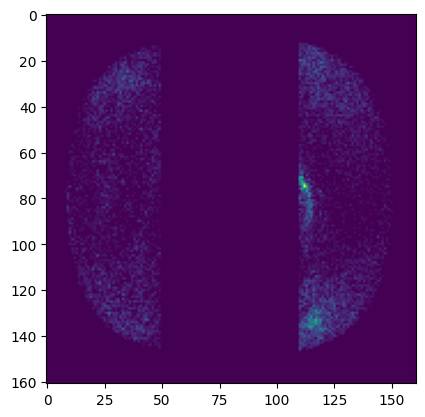

In [33]:
plt.imshow(result[-12])

In [10]:
dataset.glac_chunk.keys()

Index(['Cloud_ID', 'Time [m]', 'Magnitude', 'Glac_start_ind', 'Glac_peak_ind',
       'Linear', 'line_rmse', 'Rate_arr', 'Mean_glac_rate',
       'Glaciation time [h]', 'tracknumber', 'is_large_pix_cloud',
       'is_cot_valid_cloud', 'is_ctp_valid_cloud', 'is_liq', 'is_mix',
       'is_ice', 'max_water_frac', 'max_ice_fraction', 'avg_size[km]',
       'max_size[km]', 'min_size[km]', 'avg_size[px]', 'max_size[px]',
       'min_size[px]', 'track_start_time', 'track_length', 'avg_cot',
       'avg_ctp', 'avg_ctt', 'glaciation_start_time', 'glaciation_end_time',
       'avg_lat', 'avg_lon', 'start_ice_fraction', 'end_ice_fraction',
       'ice_frac_hist', 'cot_hist', 'cot_std_hist', 'cot_nan_frac_hist',
       'ctp_hist', 'ctp_std_hist', 'ctp_nan_frac_hist', 'ctt_hist',
       'ctt_std_hist', 'lat_hist', 'lon_hist', 'size_hist_km', 'min_temp',
       'max_temp', 'pole', 'Hemisphere', 'Lifetime [h]', 'Radius [km]',
       'track_end_time', 'Level', 'Optical Thickness', 'Cloud type', 'Seaso

In [11]:
# Set up analysis dataframe
dataset = ChunkLoader(years,config=config, load_init_chunk=False)
heatmaps_glac = dataset.execute_analysis(extract_glac_heatmap,load_glac=True, load_clouds=False)#,glac_columns=["avg_lon","avg_lat"])

Cloud_fps: {2007: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2007_all.parquet', 2008: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2008_all.parquet', 2009: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2009_all.parquet', 2010: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2010_all.parquet', 2011: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2011_all.parquet', 2012: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2012_all.parquet', 2013: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2013_all.parquet', 2014: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2014_all.parquet', 2015: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2015_all.parquet', 2016: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2016_all.parquet'}


Loading years: 100%|██████████| 10/10 [00:15<00:00,  1.57s/year]


In [13]:
heatmaps_glac_arr = np.array(heatmaps_glac)
np.save( "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/heatmap_glac_data.npy",heatmaps_glac_arr)

In [14]:
heatmaps_cloud_arr = np.load("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/heatmap_data.npy")

In [16]:
import matplotlib.pyplot as plt

/tmp/ipykernel_23354/32737275.py:1: RuntimeWarning: invalid value encountered in divide
  plt.imshow((heatmaps_glac_arr/heatmaps_cloud_arr)[7,:,:],interpolation='none',vmin=0,vmax=0.15)


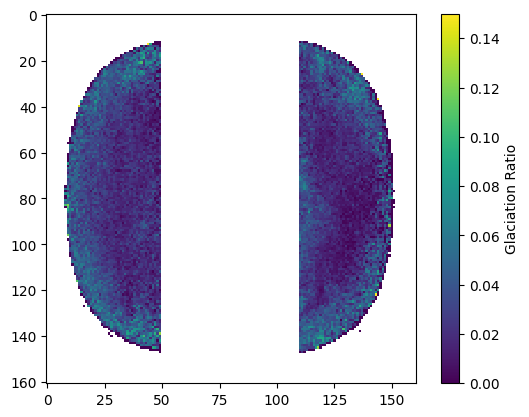

In [24]:
plt.imshow((heatmaps_glac_arr/heatmaps_cloud_arr)[7,:,:],interpolation='none',vmin=0,vmax=0.15)
plt.colorbar(label='Glaciation Ratio')

/tmp/ipykernel_23354/1618057684.py:1: RuntimeWarning: invalid value encountered in divide
  heatmaps_glac_arr/heatmaps_cloud_arr


array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       ...,

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan

In [4]:
# Set up analysis dataframe
dataset = ChunkLoader(years,config=config, load_init_chunk=False)
heatmaps = dataset.execute_analysis(extract_heatmap,load_glac=False,cloud_columns=["avg_lon","avg_lat"])

Cloud_fps: {2007: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2007_all.parquet', 2008: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2008_all.parquet', 2009: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2009_all.parquet', 2010: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2010_all.parquet', 2011: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2011_all.parquet', 2012: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2012_all.parquet', 2013: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2013_all.parquet', 2014: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2014_all.parquet', 2015: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2015_all.parquet', 2016: '/nfs/ch4/wolke_scratch/dnikolo/Final_results/2016_all.parquet'}


Loading years: 100%|██████████| 10/10 [09:22<00:00, 56.29s/year]


In [7]:
heatmaps_arr = np.array(heatmaps)

In [12]:
heatmaps_arr.mean(axis=0)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [18]:
np.save( "/cluster/work/climate/dnikolo/n2o/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/heatmap_data.npy",heatmaps_arr)

In [19]:
np.load("/cluster/work/climate/dnikolo/n2o/Glaciation_time_estimator/Result_analysis/Publication_figures/Multiyear_analysis/heatmap_data.npy")

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.